In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [15]:
dataset_folder = "/content/drive/MyDrive/MachineLearningCVE"

print("Files in folder:")
print(os.listdir(dataset_folder))

Files in folder:
['Wednesday-workingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']


In [16]:
csv_files = []

for root, dirs, files in os.walk(dataset_folder):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Total CSV files found:", len(csv_files))
for f in csv_files:
    print(f)

Total CSV files found: 8
/content/drive/MyDrive/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [17]:
df_list = []

for file in csv_files:
    try:
        temp_df = pd.read_csv(file, low_memory=False)
        df_list.append(temp_df)
        print(f"Loaded: {file} | Shape: {temp_df.shape}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

df = pd.concat(df_list, ignore_index=True)
print("Combined dataset shape:", df.shape)

Loaded: /content/drive/MyDrive/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv | Shape: (692703, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv | Shape: (445909, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv | Shape: (170366, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv | Shape: (288602, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv | Shape: (191033, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv | Shape: (529918, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv | Shape: (286467, 79)
Loaded: /content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv | Shape: (225745, 79)
Combined dataset shape: (2830743, 79)


In [18]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [19]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (2520798, 79)


In [20]:
target_col = "Label"

X = df.drop(columns=[target_col])
y = df[target_col]

X = X.select_dtypes(include=[np.number])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2520798, 78)
y shape: (2520798,)


In [21]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Classes:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> DoS GoldenEye
4 -> DoS Hulk
5 -> DoS Slowhttptest
6 -> DoS slowloris
7 -> FTP-Patator
8 -> Heartbleed
9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack � Brute Force
13 -> Web Attack � Sql Injection
14 -> Web Attack � XSS


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2016638, 78)
Test: (504160, 78)


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [24]:
y_pred = rf_model.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.998167248492542

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.87      0.77      0.82       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack � Brute Force       0.74      0.82      0.78      

In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(20)

,Feature,Importance
41,Packet Length Std,0.066643
42,Packet Length Variance,0.060811
54,Avg Bwd Segment Size,0.057096
39,Max Packet Length,0.048440
13,Bwd Packet Length Std,0.044501
10,Bwd Packet Length Max,0.041947
52,Average Packet Size,0.039023
6,Fwd Packet Length Max,0.031902
63,Subflow Fwd Bytes,0.031662
4,Total Length of Fwd Packets,0.030359


In [27]:
import joblib

output_folder = "/content/drive/MyDrive/CICIDS2017_Output"
os.makedirs(output_folder, exist_ok=True)

joblib.dump(rf_model, os.path.join(output_folder, "rf_model.pkl"))
joblib.dump(label_encoder, os.path.join(output_folder, "label_encoder.pkl"))
feature_importance.to_csv(os.path.join(output_folder, "feature_importance.csv"), index=False)

print("Saved to:", output_folder)

Saved to: /content/drive/MyDrive/CICIDS2017_Output


In [28]:
import time
import matplotlib.pyplot as plt

In [29]:
n_estimators_list = [10, 50, 100, 150]

accuracies = []
train_times = []

for n in n_estimators_list:
    print(f"\nTraining with n_estimators = {n}")

    start_time = time.time()

    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    end_time = time.time()

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    train_times.append(end_time - start_time)

    print(f"Accuracy: {acc}")
    print(f"Time: {end_time - start_time} seconds")


Training with n_estimators = 10
Accuracy: 0.9982446048873374
Time: 153.62718296051025 seconds

Training with n_estimators = 50
Accuracy: 0.9983437797524596
Time: 740.9503562450409 seconds

Training with n_estimators = 100
Accuracy: 0.9983655982227864
Time: 1370.8797101974487 seconds

Training with n_estimators = 150
Accuracy: 0.9983556807362742
Time: 2040.8561055660248 seconds


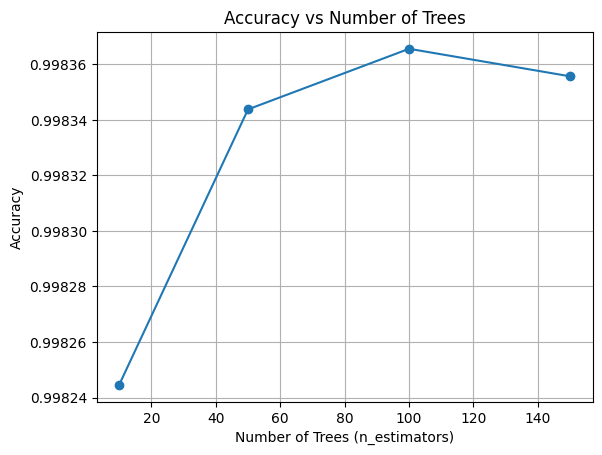

In [30]:
plt.figure()
plt.plot(n_estimators_list, accuracies, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.grid()

plt.show()

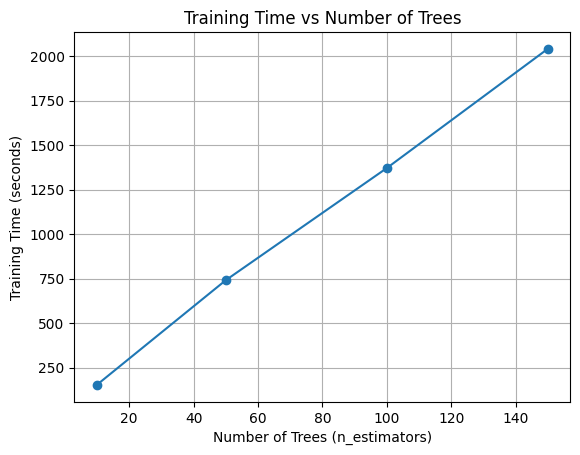

In [31]:
plt.figure()
plt.plot(n_estimators_list, train_times, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time vs Number of Trees")
plt.grid()

plt.show()

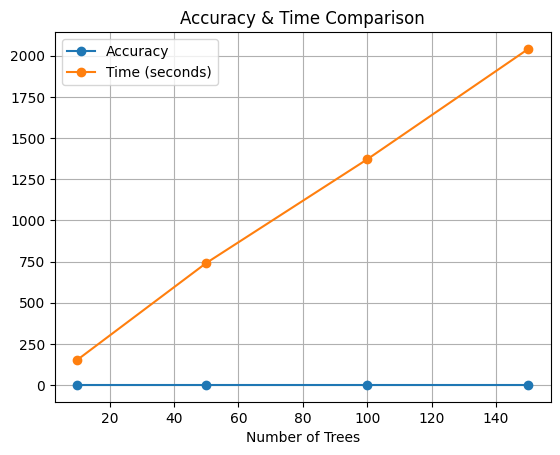

In [32]:
plt.figure()

plt.plot(n_estimators_list, accuracies, marker='o', label="Accuracy")
plt.plot(n_estimators_list, train_times, marker='o', label="Time (seconds)")

plt.xlabel("Number of Trees")
plt.title("Accuracy & Time Comparison")
plt.legend()
plt.grid()

plt.show()